![logo](img/logoitqv1.jpg)
<br>

# 0.1 PAO25-25- REGRESIÓN LINEAL


<br>

![python](img/python_logo.png)

<br>

*Alexis González*

<br>

[link de Git Hub](https://github.com/Mathias255/Machine-E-learning.git)

In [14]:
import numpy as np
from math import sqrt
from pprint import pprint
from sklearn import datasets, linear_model, metrics
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, train_test_split, cross_val_score
from sklearn import preprocessing
from sklearn.metrics import make_scorer, mean_squared_error
import matplotlib.pyplot as plt

# Carga de datos (California Housing)
datos = datasets.fetch_california_housing()

X = datos.data
y = datos.target

print('Dimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)

# Mostrar nombres de las variables
print('\nCaracterísticas:')
print(datos.feature_names)

Dimensiones de X: (20640, 8)
Dimensiones de y: (20640,)

Características:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [15]:
# # Métricas de evaluación.
metricas = {
'MAE': 'neg_mean_absolute_error',
'RMSE': make_scorer(lambda y, y_pred:
                    sqrt(metrics.mean_squared_error(y, y_pred)),
                    greater_is_better=False),
'MAPE': make_scorer(lambda y, y_pred:
                    np.mean(np.abs((y - y_pred) / y)) * 100,
                    greater_is_better=False),
'R2': 'r2',}

In [16]:
# 1) Partición de datos externa
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_training))

(16512, 8)


In [17]:
# 2) Extracción de características
# 3) Selección de atributos
# 4) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
stdr_trained = standardizer.fit(X_training)
X_stdr = stdr_trained.transform(X_training)

In [18]:
 # 5) Construcción del algoritmo de aprendizaje.
reg = linear_model.LinearRegression(fit_intercept=True)

In [19]:
 # 5.1) Validación cruzada interna
# Extraer directamente resultados del error para cada bolsa, en lugar de las predicciones
cross_val_results = cross_validate(reg, X_stdr, y_training,
cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)
#print("cross_val_MAE: %0.4f +/- %0.4f" % (-cross_val_results.mean(),cross_val_results.std()))
print(cross_val_results)

{'fit_time': array([0.00876522, 0.00900102, 0.00700021, 0.0079124 , 0.00801873]), 'score_time': array([0.00300217, 0.00399876, 0.00409842, 0.00309801, 0.00311589]), 'test_MAE': array([-0.54071407, -0.52878981, -0.51274193, -0.53512422, -0.52793364]), 'test_RMSE': array([-0.73389779, -0.72516701, -0.69726867, -0.73337185, -0.71284225]), 'test_MAPE': array([-31.74769388, -31.65516613, -30.97054077, -32.61432353,
       -30.685065  ]), 'test_R2': array([0.60970239, 0.60411343, 0.6354319 , 0.60076148, 0.60727452])}


In [20]:
 # 5.2) Entrenamiento con todos los datos para obtener los coeficientes del modelo.
model = reg.fit(X_stdr, y_training)

# Obtención de los coeficientes del modelo.
w = model.coef_
print('Model coeficients: \n', w)

# Obtención del término independiente del modelo.
w_0 = model.intercept_
print('\nTérmino independiente: ', w_0)

Model coeficients: 
 [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]

Término independiente:  2.071946937378619


In [21]:
# ---- PREDICCIÓN ---- #

In [22]:
# 6) Extracción de las características de test
# 7) Selección de los atributos de test
# 8) Estandarización de las característiacs de test
X_test_stdr = stdr_trained.transform(X_testing)

In [23]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)

In [26]:
# Cálculo de las métricas de evaluación
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)

MSE = metrics.mean_squared_error(y_testing, y_pred_test)

RMSE = sqrt(MSE)

MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test)

R2 = metrics.r2_score(y_testing, y_pred_test)

print('MAE: %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('MAPE: %.4f' % MAPE)
print('R2: %.4f' % R2)

MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456
MAPE: 0.3195
R2: 0.5758


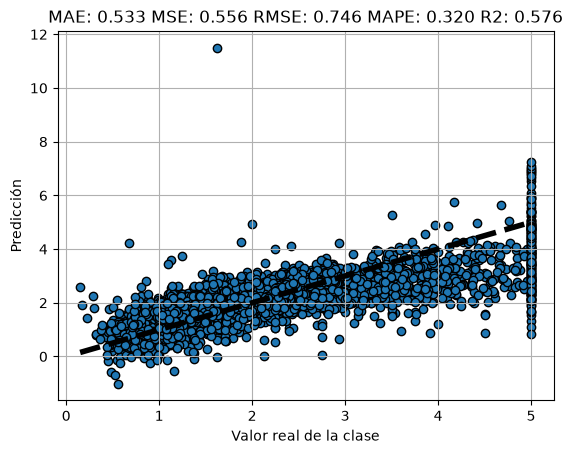

In [27]:
 # Gráfica de realidad vs. predicción.
fig, ax = plt.subplots()
ax.scatter(y_testing, y_pred_test, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Valor real de la clase')
ax.set_ylabel('Predicción')
plt.title("MAE: %.3f MSE: %.3f RMSE: %.3f MAPE: %.3f R2: %.3f" %
         (MAE,MSE,RMSE,MAPE,R2))

plt.grid()
plt.show()